# Group Work - Advanced Data Analysis and Machine Learning 
**Topic:** NASA Turbofan Level A2  
**Team:** Ahson Anwaar, Ondřej Beneš, Dan Valníček  
**Date:** 11.9.2026

## Imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import label
from sympy.abc import alpha

## Data loading
Loading all the data in the format specified by the attached dataset description.

In [23]:
columns = [
    "unit number",
    "time in cycles",
    "operational setting 1",
    "operational setting 2",
    "operational setting 3",
    *[f"sensor measurement {i}" for i in range(1, 22)],
]

# Load all datasets
train = {}
test = {}
rul = {}

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    train[fd] = pd.read_csv(
        f"./data/train_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns,
    )

    test[fd] = pd.read_csv(
        f"./data/test_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=columns,
    )

    rul[fd] = pd.read_csv(
        f"./data/RUL_{fd}.txt",
        sep=r"\s+",
        header=None,
        names=["RUL"],
    )

for fd in train:
    print(f"{fd}:")
    print(f"  Train: {train[fd].shape}")
    print(f"  Test:  {test[fd].shape}")
    print(f"  RUL:   {rul[fd].shape}")
    print()

print(train["FD001"].head())

FD001:
  Train: (20631, 26)
  Test:  (13096, 26)
  RUL:   (100, 1)

FD002:
  Train: (53759, 26)
  Test:  (33991, 26)
  RUL:   (259, 1)

FD003:
  Train: (24720, 26)
  Test:  (16596, 26)
  RUL:   (100, 1)

FD004:
  Train: (61249, 26)
  Test:  (41214, 26)
  RUL:   (248, 1)

   unit number  time in cycles  operational setting 1  operational setting 2  \
0            1               1                -0.0007                -0.0004   
1            1               2                 0.0019                -0.0003   
2            1               3                -0.0043                 0.0003   
3            1               4                 0.0007                 0.0000   
4            1               5                -0.0019                -0.0002   

   operational setting 3  sensor measurement 1  sensor measurement 2  \
0                  100.0                518.67                641.82   
1                  100.0                518.67                642.15   
2                  100.0       

## Exploration

### Initial data visualization

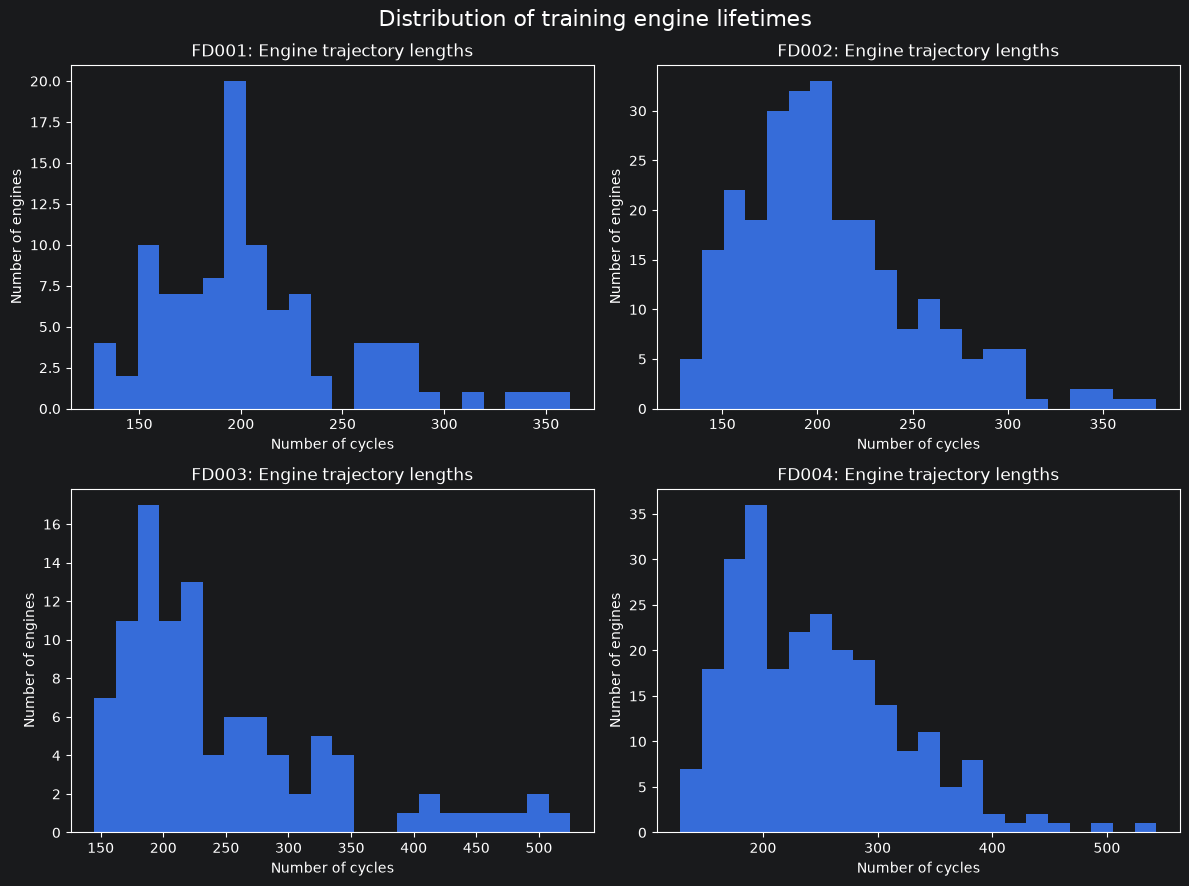

In [24]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, fd in enumerate(train):
    trajectory_lengths = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    axes[i].hist(
        trajectory_lengths,
        bins=22
    )

    axes[i].set_title(f"{fd}: Engine trajectory lengths")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel("Number of engines")

fig.suptitle(
    "Distribution of training engine lifetimes",
    fontsize=16
)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, fd in enumerate(train):

    trajectory_lengths = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    axes[i].hist(
        trajectory_lengths,
        bins=22
    )

    axes[i].set_title(f"{fd}: Engine trajectory lengths")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel("Number of engines")

fig.suptitle(
    "Distribution of training engine lifetimes",
    fontsize=16
)

plt.tight_layout()
plt.show()


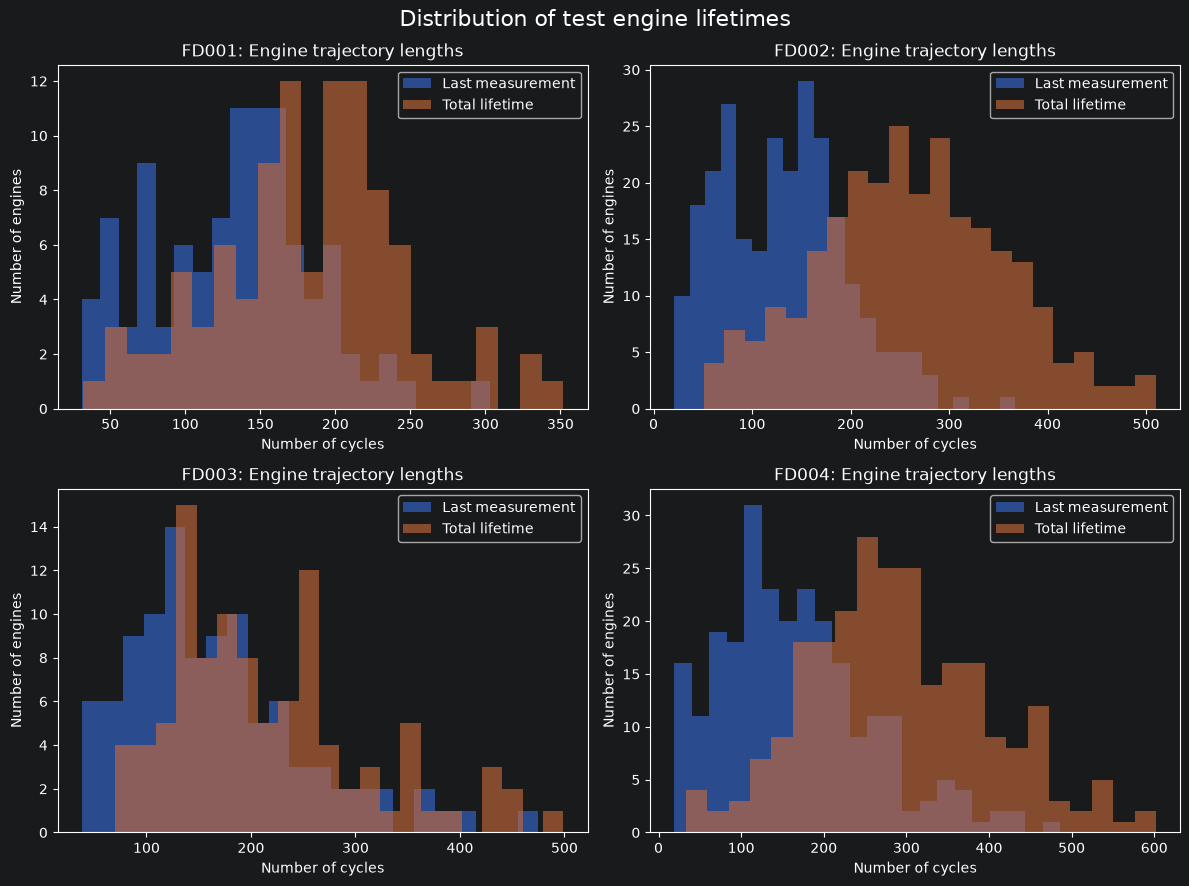

In [30]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, fd in enumerate(test):
    trajectory_lengths = (
        test[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )
    rul_series = rul[fd]['RUL'].copy()
    rul_series = rul_series.index + 1
    failure_time = trajectory_lengths + rul_series

    axes[i].hist(
        trajectory_lengths,
        alpha=0.6,
        label='Last measurement',
        bins=22
    )
    axes[i].hist(
        failure_time,
        alpha=0.6,
        label="Total lifetime",
        bins=22
    )
    axes[i].legend()
    axes[i].set_title(f"{fd}: Engine trajectory lengths")
    axes[i].set_xlabel("Number of cycles")
    axes[i].set_ylabel("Number of engines")

fig.suptitle(
    "Distribution of test engine lifetimes",
    fontsize=16
)

plt.tight_layout()
plt.show()


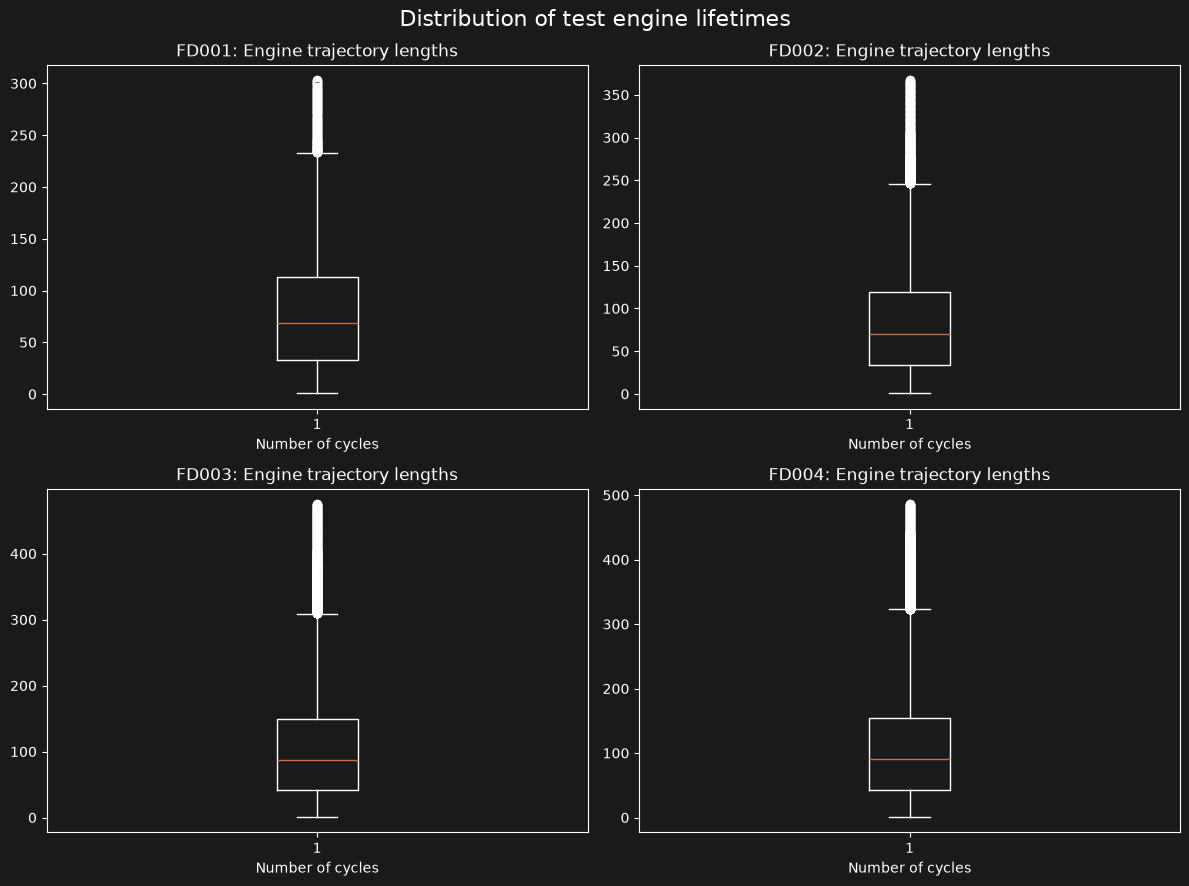

In [34]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

axes = axes.flatten()

for i, fd in enumerate(test):
    axes[i].boxplot(test[fd]['time in cycles'])
    axes[i].set_title(f"{fd}: Engine trajectory lengths")
    axes[i].set_xlabel("Number of cycles")

fig.suptitle(
    "Distribution of test engine lifetimes",
    fontsize=16
)

plt.tight_layout()
plt.show()


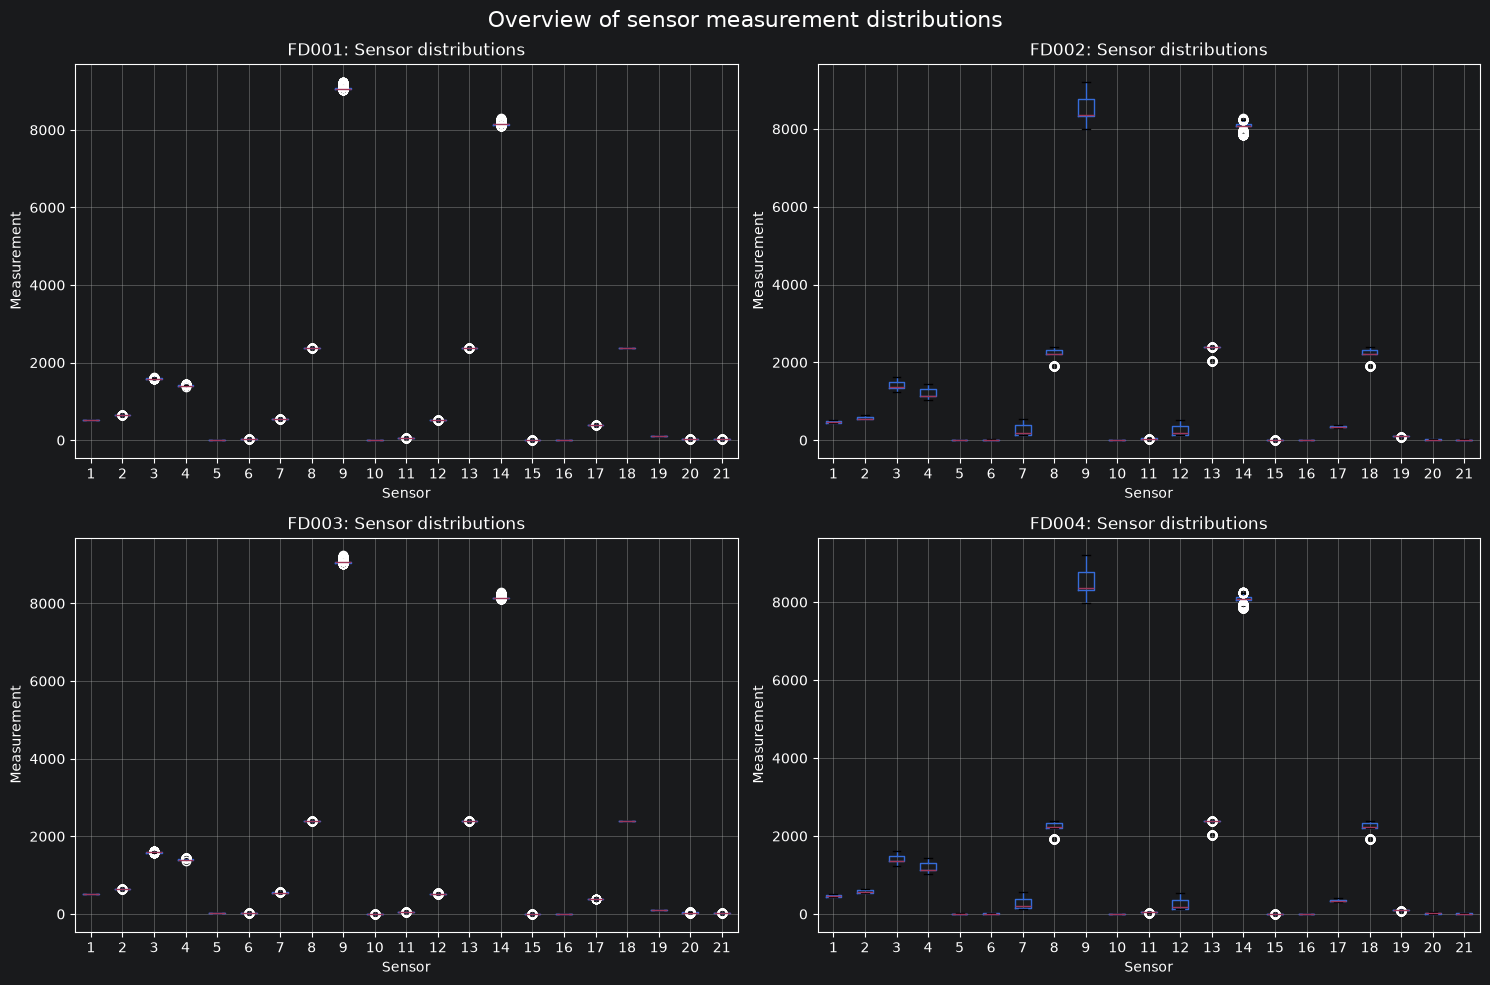

In [4]:
sensor_columns = [
    f"sensor measurement {i}"
    for i in range(1, 22)
]

sensor_numbers = list(range(1, 22))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

axes = axes.flatten()

for i, fd in enumerate(train):
    train[fd][sensor_columns].boxplot(
        ax=axes[i]
    )

    axes[i].set_xticklabels(
        sensor_numbers
    )

    axes[i].set_title(f"{fd}: Sensor distributions")
    axes[i].set_xlabel("Sensor")
    axes[i].set_ylabel("Measurement")

fig.suptitle(
    "Overview of sensor measurement distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

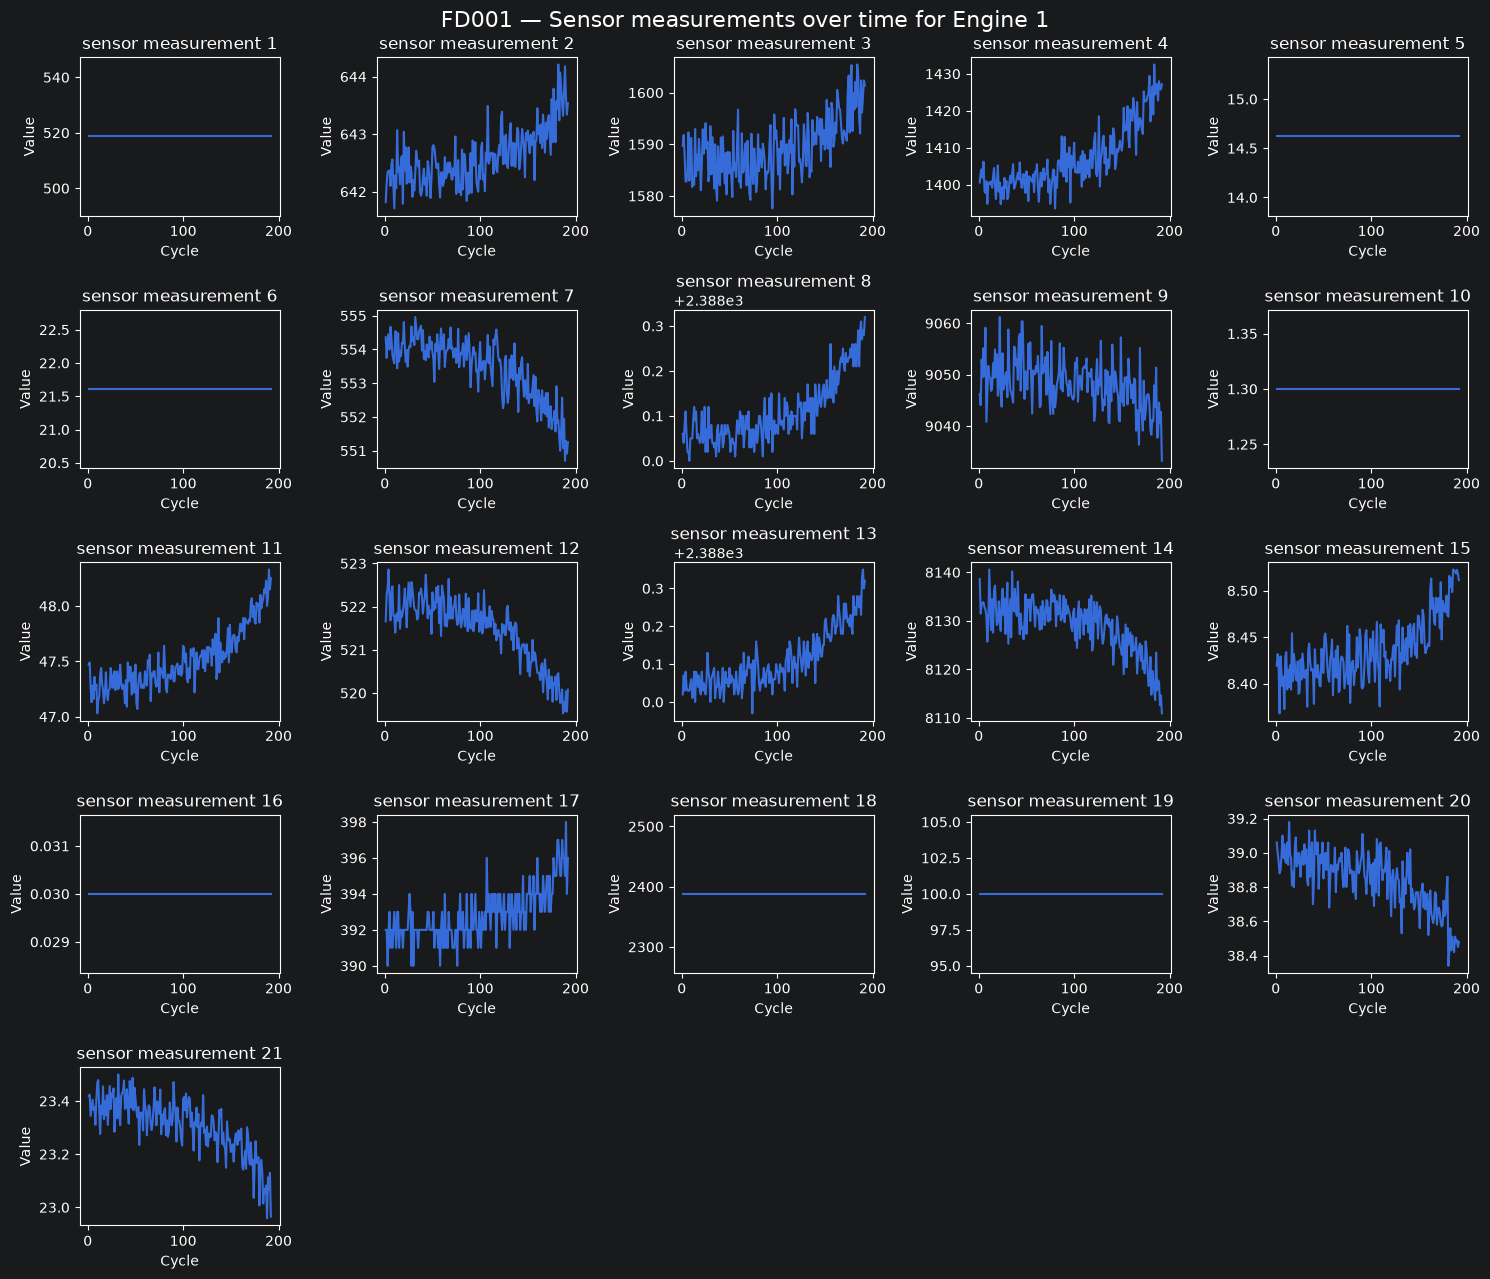

In [5]:
fd = "FD001"

engine = train[fd][
    train[fd]["unit number"] == 1
    ]

fig, axes = plt.subplots(
    5,
    5,
    figsize=(15, 13)
)

axes = axes.flatten()

for i, sensor in enumerate(sensor_columns):
    axes[i].plot(
        engine["time in cycles"],
        engine[sensor]
    )

    axes[i].set_title(sensor)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel("Value")

# Hide unused subplot
for i in range(len(sensor_columns), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    "FD001 — Sensor measurements over time for Engine 1",
    fontsize=16
)

plt.tight_layout()
plt.show()

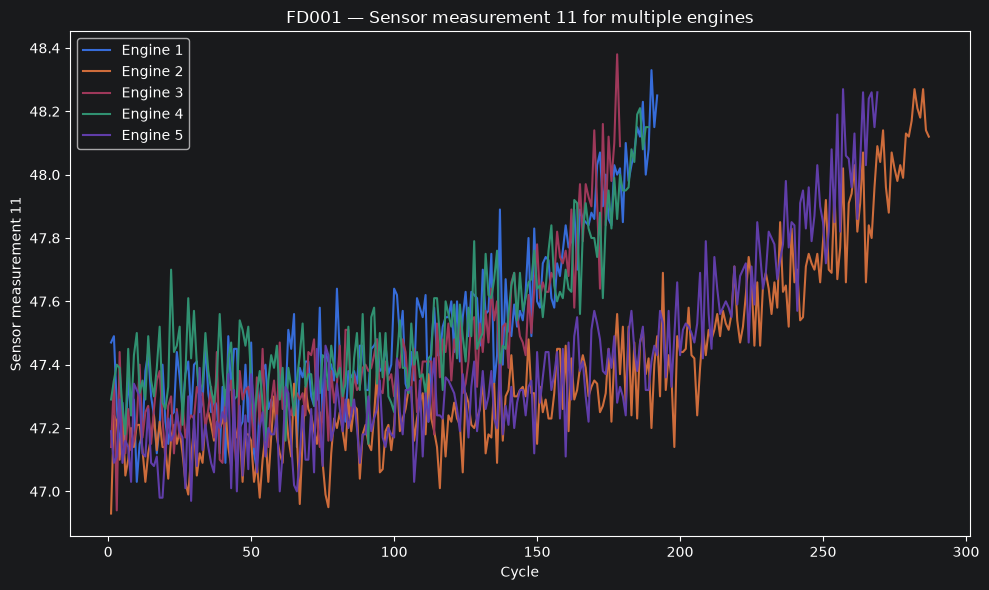

In [6]:
fd = "FD001"

plt.figure(figsize=(10, 6))

for unit in range(1, 6):
    engine = train[fd][
        train[fd]["unit number"] == unit
        ]

    plt.plot(
        engine["time in cycles"],
        engine["sensor measurement 11"],
        label=f"Engine {unit}"
    )

plt.xlabel("Cycle")
plt.ylabel("Sensor measurement 11")
plt.title(
    "FD001 — Sensor measurement 11 for multiple engines"
)

plt.legend()

plt.tight_layout()
plt.show()

### Issue identification

#### Missing values

In [7]:
for fd in train:

    print(f"\n{fd}")

    train_missing = train[fd].isna().sum()
    test_missing = test[fd].isna().sum()

    print("Train missing values:", train_missing.sum())
    print("Test missing values: ", test_missing.sum())

    if train_missing.sum() > 0:
        print("\nTrain missing by variable:")
        print(train_missing[train_missing > 0])

    if test_missing.sum() > 0:
        print("\nTest missing by variable:")
        print(test_missing[test_missing > 0])


FD001
Train missing values: 0
Test missing values:  0

FD002
Train missing values: 0
Test missing values:  0

FD003
Train missing values: 0
Test missing values:  0

FD004
Train missing values: 0
Test missing values:  0


The dataset does not have any missing values.

#### Series synchronicity

In [8]:
for fd in train:
    trajectory_lengths = (
        train[fd]
        .groupby("unit number")["time in cycles"]
        .max()
    )

    print(f"\n{fd}")
    print(f"Number of engines: {len(trajectory_lengths)}")
    print(f"Minimum length:    {trajectory_lengths.min()}")
    print(f"Maximum length:    {trajectory_lengths.max()}")
    print(f"Mean length:       {trajectory_lengths.mean():.1f}")
    print(f"Median length:     {trajectory_lengths.median():.1f}")


FD001
Number of engines: 100
Minimum length:    128
Maximum length:    362
Mean length:       206.3
Median length:     199.0

FD002
Number of engines: 260
Minimum length:    128
Maximum length:    378
Mean length:       206.8
Median length:     199.0

FD003
Number of engines: 100
Minimum length:    145
Maximum length:    525
Mean length:       247.2
Median length:     220.5

FD004
Number of engines: 249
Minimum length:    128
Maximum length:    543
Mean length:       246.0
Median length:     234.0


The train data consist of separate time series for individual engines. All engine trajectories start at cycle 1, but they have different numbers of cycles and therefore different endpoints. Consequently, the time series are not synchronized at the end.

#### Constant sensor outputs

In [9]:
for fd in train:
    print(f"\n{fd}")

    unique_values = train[fd].nunique()

    print("\nVariables with only one unique value:")

    print(
        unique_values[
            unique_values == 1
            ]
    )


FD001

Variables with only one unique value:
operational setting 3    1
sensor measurement 1     1
sensor measurement 5     1
sensor measurement 10    1
sensor measurement 16    1
sensor measurement 18    1
sensor measurement 19    1
dtype: int64

FD002

Variables with only one unique value:
Series([], dtype: int64)

FD003

Variables with only one unique value:
operational setting 3    1
sensor measurement 1     1
sensor measurement 5     1
sensor measurement 16    1
sensor measurement 18    1
sensor measurement 19    1
dtype: int64

FD004

Variables with only one unique value:
Series([], dtype: int64)


Several sensors have a constant output in set 1 and 3 in both the training and testing datasets.